# Pass2b GCD reprocessing — inspection
Compare `HESE_CausalQTot` / `HESE_VHESelfVeto` (original GCD) with `CausalQTot_pass2b` / `VHESelfVeto_pass2b` (pass2b GCD).

In [17]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

HDF5 = '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/pass2b_gcd/merged/EvtGen_merged.h5'

with h5py.File(HDF5, 'r') as f:
    run       = f['HESE_CausalQTot']['Run'][:]
    event     = f['HESE_CausalQTot']['Event'][:]
    qtot_orig = f['HESE_CausalQTot']['value'][:]
    qtot_p2b  = f['CausalQTot_pass2b']['value'][:]
    veto_orig = f['HESE_VHESelfVeto']['value'][:].astype(bool)
    veto_p2b  = f['VHESelfVeto_pass2b']['value'][:].astype(bool)
    etot      = f['RecoETot']['value'][:]

print(f'Total events: {len(qtot_orig)}')

Total events: 188


## CausalQTot distributions

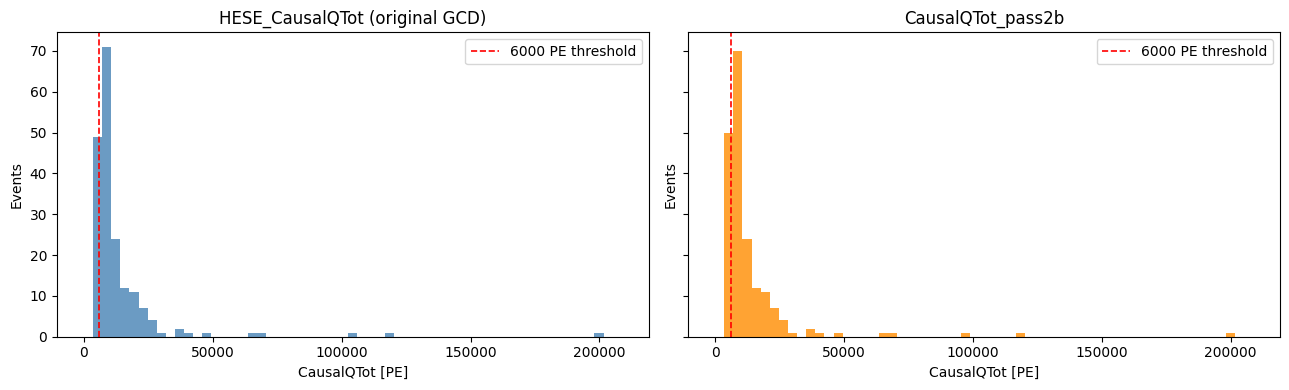

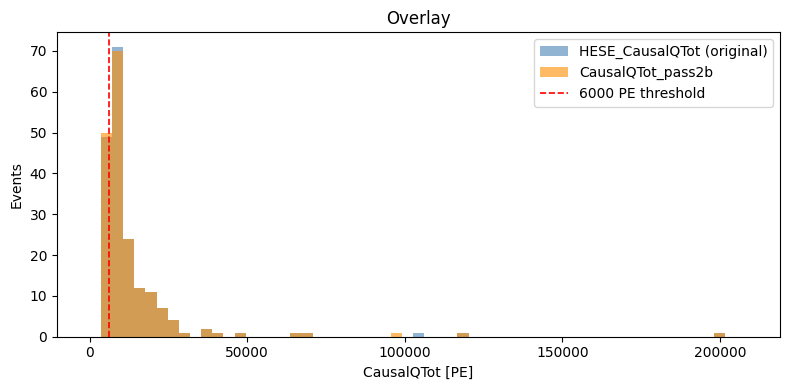

In [18]:
bins = np.linspace(0, max(qtot_orig.max(), qtot_p2b.max()) * 1.05, 60)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, vals, label, color in [
    (axes[0], qtot_orig, 'HESE_CausalQTot (original GCD)', 'steelblue'),
    (axes[1], qtot_p2b,  'CausalQTot_pass2b',              'darkorange'),
]:
    ax.hist(vals, bins=bins, color=color, alpha=0.8)
    ax.axvline(6000, color='red', linestyle='--', linewidth=1.2, label='6000 PE threshold')
    ax.set_xlabel('CausalQTot [PE]')
    ax.set_ylabel('Events')
    ax.set_title(label)
    ax.legend()

fig.tight_layout()
plt.show()

# Overlay
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(qtot_orig, bins=bins, color='steelblue',  alpha=0.6, label='HESE_CausalQTot (original)')
ax2.hist(qtot_p2b,  bins=bins, color='darkorange', alpha=0.6, label='CausalQTot_pass2b')
ax2.axvline(6000, color='red', linestyle='--', linewidth=1.2, label='6000 PE threshold')
ax2.set_xlabel('CausalQTot [PE]')
ax2.set_ylabel('Events')
ax2.set_title('Overlay')
ax2.legend()
fig2.tight_layout()
plt.show()

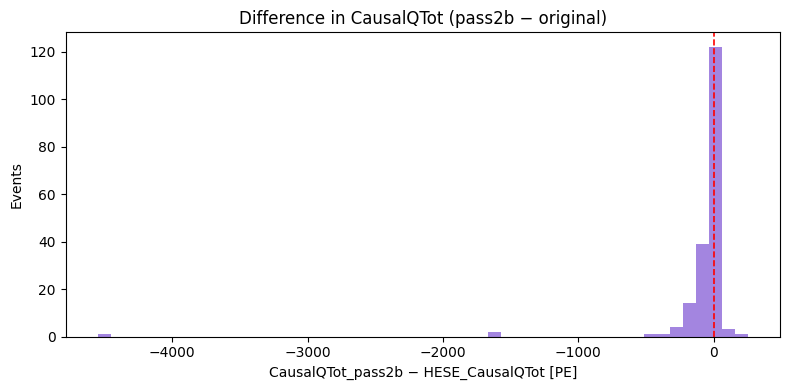

Mean   : -78.6 PE
Median : -1.8 PE
Std    : 373.8 PE
Min    : -4546.8 PE
Max    : 249.1 PE


In [19]:
diff = qtot_p2b - qtot_orig

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(diff, bins=50, color='mediumpurple', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.2)
ax.set_xlabel('CausalQTot_pass2b − HESE_CausalQTot [PE]')
ax.set_ylabel('Events')
ax.set_title('Difference in CausalQTot (pass2b − original)')
fig.tight_layout()
plt.show()

print(f'Mean   : {diff.mean():.1f} PE')
print(f'Median : {np.median(diff):.1f} PE')
print(f'Std    : {diff.std():.1f} PE')
print(f'Min    : {diff.min():.1f} PE')
print(f'Max    : {diff.max():.1f} PE')

## Events below 6000 PE

In [20]:
threshold = 6000

n_orig_below = (qtot_orig < threshold).sum()
n_p2b_below  = (qtot_p2b  < threshold).sum()
n_total      = len(qtot_orig)

print(f'Events below {threshold} PE')
print(f'  HESE_CausalQTot (original) : {n_orig_below:3d} / {n_total}  ({100*n_orig_below/n_total:.1f}%)')
print(f'  CausalQTot_pass2b          : {n_p2b_below:3d} / {n_total}  ({100*n_p2b_below/n_total:.1f}%)')
print()

both_below   = ((qtot_orig < threshold) & (qtot_p2b < threshold)).sum()
orig_only    = ((qtot_orig < threshold) & (qtot_p2b >= threshold)).sum()
p2b_only     = ((qtot_orig >= threshold) & (qtot_p2b < threshold)).sum()

print('Cross-check (events below threshold in one but not both):')
print(f'  Both below   : {both_below}')
print(f'  Original only: {orig_only}')
print(f'  pass2b only  : {p2b_only}')

Events below 6000 PE
  HESE_CausalQTot (original) :   0 / 188  (0.0%)
  CausalQTot_pass2b          :   1 / 188  (0.5%)

Cross-check (events below threshold in one but not both):
  Both below   : 0
  Original only: 0
  pass2b only  : 1


In [21]:
threshold = 6000

mask_below = (qtot_orig < threshold) | (qtot_p2b < threshold)
print(f'Events below {threshold} PE in at least one variable ({mask_below.sum()} total):')
print(f'{"Run":>10}  {"Event":>10}  {"RecoETot [GeV]":>16}  {"HESE_CausalQTot":>16}  {"CausalQTot_pass2b":>18}')
print('-' * 80)
for i in np.where(mask_below)[0]:
    flag_orig = '*' if qtot_orig[i] < threshold else ' '
    flag_p2b  = '*' if qtot_p2b[i]  < threshold else ' '
    print(f'{run[i]:>10}  {event[i]:>10}  {etot[i]:>16.1f}  {qtot_orig[i]:>15.1f}{flag_orig}  {qtot_p2b[i]:>17.1f}{flag_p2b}')

Events below 6000 PE in at least one variable (1 total):
       Run       Event    RecoETot [GeV]   HESE_CausalQTot   CausalQTot_pass2b
--------------------------------------------------------------------------------
    126359     9400616           25268.2           6008.4              5862.9*


## VHESelfVeto counts

In [22]:
mask_changed = veto_orig != veto_p2b
print(f'Events where VHESelfVeto decision changed ({mask_changed.sum()} total):')
print(f'{"Run":>10}  {"Event":>10}  {"RecoETot [GeV]":>16}  {"HESE_VHESelfVeto":>18}  {"VHESelfVeto_pass2b":>20}')
print('-' * 82)
for i in np.where(mask_changed)[0]:
    arrow = f'{veto_orig[i]} -> {veto_p2b[i]}'
    print(f'{run[i]:>10}  {event[i]:>10}  {etot[i]:>16.1f}  {str(veto_orig[i]):>18}  {str(veto_p2b[i]):>20}   ({arrow})')

Events where VHESelfVeto decision changed (1 total):
       Run       Event    RecoETot [GeV]    HESE_VHESelfVeto    VHESelfVeto_pass2b
----------------------------------------------------------------------------------
    121947     7181486           74496.8               False                  True   (False -> True)


In [23]:
for label, veto in [('HESE_VHESelfVeto (original)', veto_orig),
                    ('VHESelfVeto_pass2b',           veto_p2b)]:
    n_true  = veto.sum()
    n_false = (~veto).sum()
    print(f'{label}')
    print(f'  True  (vetoed)     : {n_true:3d}  ({100*n_true/len(veto):.1f}%)')
    print(f'  False (not vetoed) : {n_false:3d}  ({100*n_false/len(veto):.1f}%)')
    print()

# Change between original and pass2b
changed = (veto_orig != veto_p2b).sum()
print(f'Events where veto decision changed: {changed}')
if changed > 0:
    orig_to_true  = ((~veto_orig) & veto_p2b).sum()
    orig_to_false = (veto_orig & (~veto_p2b)).sum()
    print(f'  Not vetoed → vetoed    : {orig_to_true}')
    print(f'  Vetoed → not vetoed    : {orig_to_false}')

HESE_VHESelfVeto (original)
  True  (vetoed)     :   0  (0.0%)
  False (not vetoed) : 188  (100.0%)

VHESelfVeto_pass2b
  True  (vetoed)     :   1  (0.5%)
  False (not vetoed) : 187  (99.5%)

Events where veto decision changed: 1
  Not vetoed → vetoed    : 1
  Vetoed → not vetoed    : 0


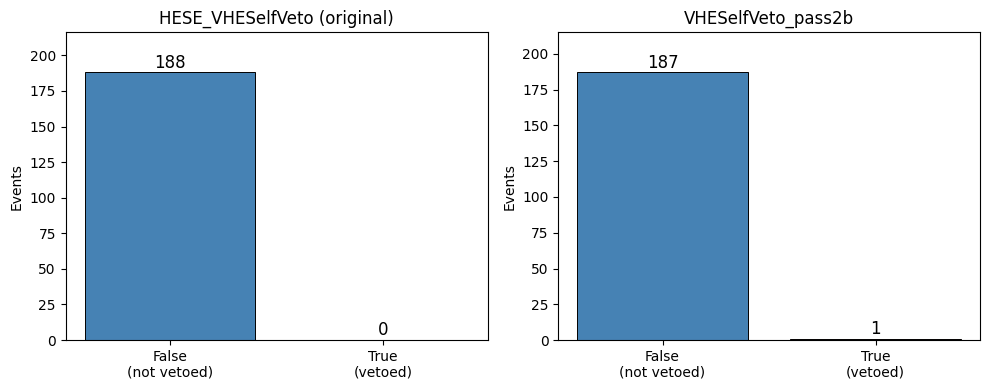

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, veto, label in [
    (axes[0], veto_orig, 'HESE_VHESelfVeto (original)'),
    (axes[1], veto_p2b,  'VHESelfVeto_pass2b'),
]:
    counts = [int((~veto).sum()), int(veto.sum())]
    bars = ax.bar(['False\n(not vetoed)', 'True\n(vetoed)'], counts,
                  color=['steelblue', 'salmon'], edgecolor='black', linewidth=0.7)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(cnt), ha='center', va='bottom', fontsize=12)
    ax.set_title(label)
    ax.set_ylabel('Events')
    ax.set_ylim(0, max(counts) * 1.15)

fig.tight_layout()
plt.show()